In [ ]:
import pandas as pd
df = pd.read_csv("stroke_data.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             10000 non-null  float64
 1   Gender          10000 non-null  object 
 2   SES             10000 non-null  object 
 3   Hypertension    10000 non-null  int64  
 4   Heart_Disease   10000 non-null  int64  
 5   BMI             10000 non-null  float64
 6   Avg_Glucose     10000 non-null  float64
 7   Diabetes        10000 non-null  int64  
 8   Smoking_Status  10000 non-null  object 
 9   Stroke          10000 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [ ]:
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report

In [ ]:
X = df.drop("Stroke", axis=1)

y = df["Stroke"]

In [ ]:
numeric_features = [
    "Age",
    "Hypertension",
    "Heart_Disease",
    "BMI",
    "Avg_Glucose",
    "Diabetes"
]


In [ ]:
categorical_features = [
    "Gender",
    "SES",
    "Smoking_Status"
]

In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [ ]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [ ]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'Hypertension',
                                                   'Heart_Disease', 'BMI',
                                                   'Avg_Glucose', 'Diabetes']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'SES',
                                                   'Smoking_Status'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
y_pred = pipeline.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.88      0.76      0.82      1404
           1       0.58      0.76      0.66       596

    accuracy                           0.76      2000
   macro avg       0.73      0.76      0.74      2000
weighted avg       0.79      0.76      0.77      2000



In [ ]:
import joblib

joblib.dump(
    pipeline,
    "stroke_pipeline.pkl"
)

['stroke_pipeline.pkl']

In [ ]:
import joblib

model = joblib.load("stroke_pipeline.pkl")

print(type(model))

<class 'sklearn.pipeline.Pipeline'>


In [ ]:
import joblib

model = joblib.load("stroke_pipeline.pkl")

print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'Hypertension',
                                                   'Heart_Disease', 'BMI',
                                                   'Avg_Glucose', 'Diabetes']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'SES',


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

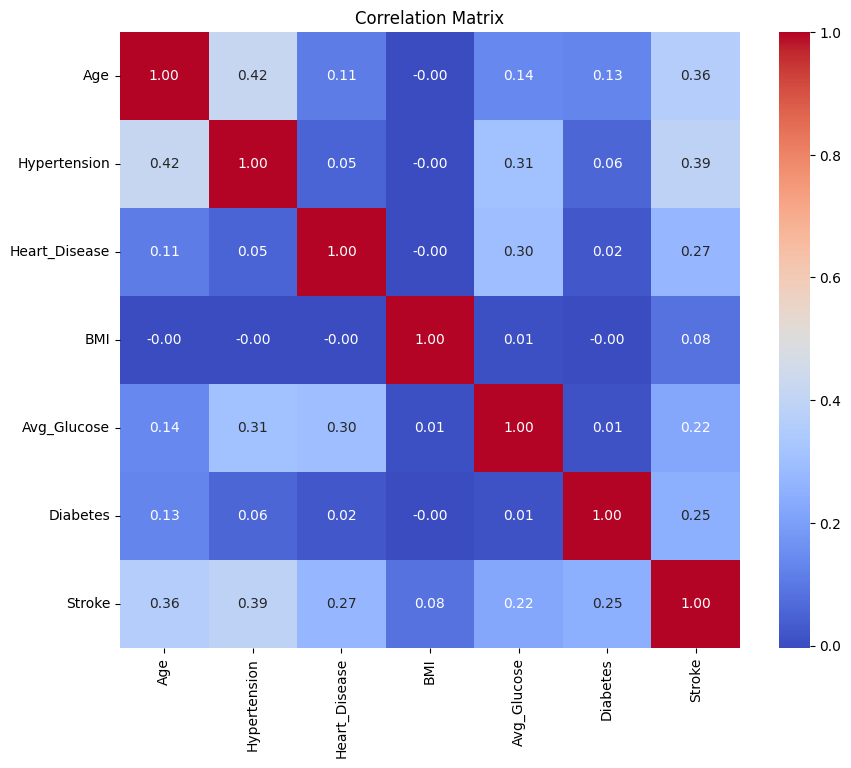

,Stroke
Stroke,1.000000
Hypertension,0.388837
Age,0.362514
Heart_Disease,0.274265
Diabetes,0.248065
Avg_Glucose,0.220624
BMI,0.083252


In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Matrix")
plt.show()
corr["Stroke"].sort_values(ascending=False)